# 10 · Calibration analysis

Compare la calibration des runs `xgb` et `xgb_calibrated` (dernier run pour chaque clé MLflow).


In [1]:

from pathlib import Path
import json
from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd
from mlflow.tracking import MlflowClient

from src.modeling.constants import CALIBRATION_ARTIFACT_PATH

EXPERIMENT_NAME = "point_total_regression"
RAW_MODEL_KEY = "xgb"
CAL_MODEL_KEY = "xgb_calibrated"
RAW_RUN_OVERRIDE: Optional[str] = None
CAL_RUN_OVERRIDE: Optional[str] = None

client = MlflowClient()


/home/ju/Documents/Dev/NBA_Predictor/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def fetch_run(model_key: str, override: Optional[str] = None):
    experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
    if experiment is None:
        raise RuntimeError(f"Experiment {EXPERIMENT_NAME} introuvable")
    if override:
        return client.get_run(override)
    runs = client.search_runs(
        [experiment.experiment_id],
        filter_string=f"params.model_key = '{model_key}'",
        order_by=["attributes.start_time DESC"],
        max_results=1,
    )
    if not runs:
        raise RuntimeError(f"Aucun run pour {model_key}")
    return runs[0]

raw_run = fetch_run(RAW_MODEL_KEY, RAW_RUN_OVERRIDE)
cal_run = fetch_run(CAL_MODEL_KEY, CAL_RUN_OVERRIDE)
print("Run raw:", raw_run.info.run_id)
print("Run calibrated:", cal_run.info.run_id)


Run raw: 8b68c9d81f2b411ea7bc0ee9e5bfbada
Run calibrated: 78f8f2cda9cb40fd9c94955ba50af36d


In [8]:

def download_csv(run_id: str, relative: str) -> pd.DataFrame:
    path = Path(client.download_artifacts(run_id, relative))
    if path.is_dir():
        csvs = list(path.glob("*.csv"))
        if not csvs:
            raise FileNotFoundError(f"Aucun CSV dans {path}")
        path = csvs[0]
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

raw_summary = download_csv(raw_run.info.run_id, f"probabilities/{RAW_MODEL_KEY}/{RAW_MODEL_KEY}_pivot_summary.csv")
raw_samples = download_csv(raw_run.info.run_id, f"probabilities/{RAW_MODEL_KEY}/samples")
cal_summary = download_csv(cal_run.info.run_id, "calibration/calibration_summary.csv")
cal_samples = download_csv(cal_run.info.run_id, "calibration/calibration_samples.csv")
calibration_path = Path(client.download_artifacts(cal_run.info.run_id, CALIBRATION_ARTIFACT_PATH))
if calibration_path.is_dir():
    calibration_path = calibration_path / Path(CALIBRATION_ARTIFACT_PATH).name
calibration_payload = json.loads(calibration_path.read_text()) if calibration_path.exists() else {}
print("Pivots calibrés:", len(calibration_payload))
display(raw_summary.head(20))
display(cal_summary.head(20))


Pivots calibrés: 27


,pivot,prob_under,prob_over
0,218.5,0.727584,0.272416
1,219.5,0.742035,0.257965
2,220.5,0.756157,0.243843
3,221.5,0.769939,0.230061
4,222.5,0.783371,0.216629
5,223.5,0.796442,0.203558
6,224.5,0.809140,0.190860
7,225.5,0.821453,0.178547
8,226.5,0.833367,0.166633
9,227.5,0.844871,0.155129


,pivot,prob_raw_mean,prob_calibrated_mean,actual_mean,count
0,218.5,0.264649,0.290083,0.290083,6474
1,219.5,0.249636,0.274791,0.274791,6474
2,220.5,0.234862,0.261816,0.261816,6474
3,221.5,0.220339,0.247915,0.247915,6474
4,222.5,0.206084,0.235249,0.235249,6474
5,223.5,0.192121,0.224745,0.224745,6474
6,224.5,0.178477,0.211616,0.211616,6474
7,225.5,0.165183,0.200031,0.200031,6474
8,226.5,0.152274,0.188292,0.188292,6474
9,227.5,0.139787,0.179333,0.179333,6474


In [9]:

comparison = cal_summary.merge(
    raw_summary[["pivot", "prob_over", "prob_under"]].rename(columns={"prob_over": "prob_over_raw"}),
    on="pivot",
    how="left",
)
comparison[["pivot", "prob_raw_mean", "prob_calibrated_mean", "actual_mean"]].head()


,pivot,prob_raw_mean,prob_calibrated_mean,actual_mean
0,218.5,0.264649,0.290083,0.290083
1,219.5,0.249636,0.274791,0.274791
2,220.5,0.234862,0.261816,0.261816
3,221.5,0.220339,0.247915,0.247915
4,222.5,0.206084,0.235249,0.235249


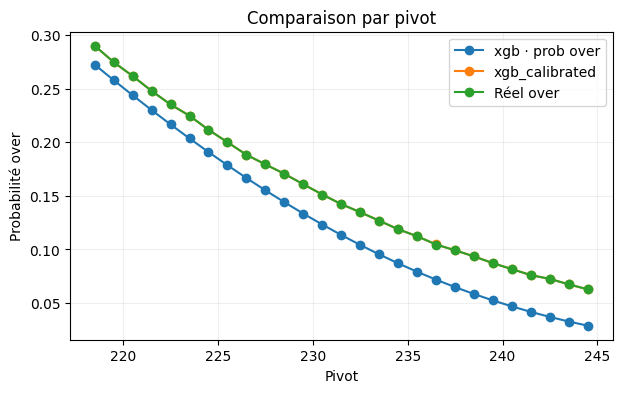

In [ ]:

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(raw_summary['pivot'], raw_summary['prob_over'], marker='o', label='xgb · prob over')
ax.plot(cal_summary['pivot'], cal_summary['prob_calibrated_mean'], marker='o', label='xgb_calibrated')
ax.plot(cal_summary['pivot'], cal_summary['actual_mean'], marker='o', label='Réel over')
ax.set_xlabel('Pivot')
ax.set_ylabel('Probabilité over')
ax.set_title('Comparaison par pivot')
ax.legend()
ax.grid(alpha=0.2)
plt.show()


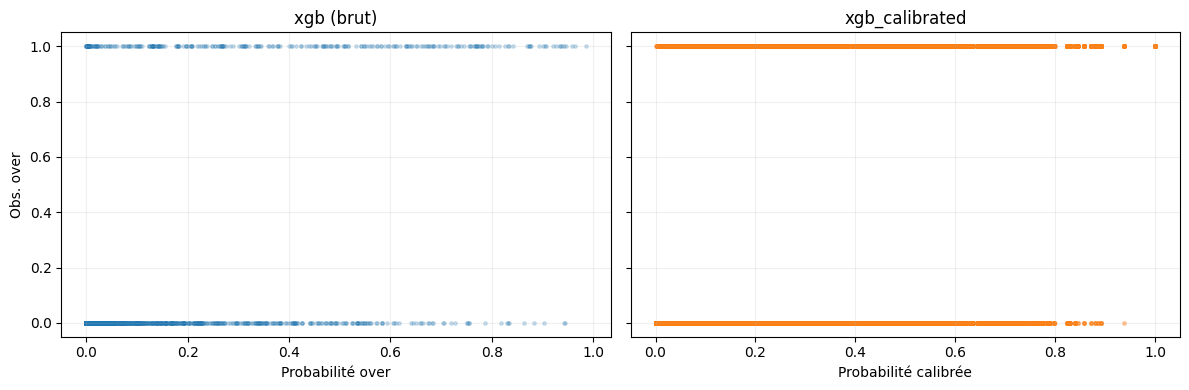

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
axes[0].scatter(raw_samples['prob_over'], raw_samples['actual'] > raw_samples['pivot'], s=6, alpha=0.2)
axes[0].set_title('xgb (brut)')
axes[0].set_xlabel('Probabilité over')
axes[0].set_ylabel('Obs. over')
axes[0].grid(alpha=0.2)
axes[1].scatter(cal_samples['prob_calibrated'], cal_samples['actual_over'], s=6, alpha=0.2, color='tab:orange')
axes[1].set_title('xgb_calibrated')
axes[1].set_xlabel('Probabilité calibrée')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [12]:

summary_compare = cal_summary.assign(
    raw_gap=(cal_summary['prob_raw_mean'] - cal_summary['actual_mean']).abs(),
    calibrated_gap=(cal_summary['prob_calibrated_mean'] - cal_summary['actual_mean']).abs(),
)
summary_compare[['pivot','raw_gap','calibrated_gap']].head()


,pivot,raw_gap,calibrated_gap
0,218.5,0.025434,0.0
1,219.5,0.025155,0.0
2,220.5,0.026954,0.0
3,221.5,0.027576,0.0
4,222.5,0.029164,0.0
